# Voice Leading Rendu GenAI — donner un spectre aux accords réparés

**Navigation** : [<< App-21 VoiceLeading (Search)](../../../Search/Applications/CSP/App-21-VoiceLeading.ipynb) | [Index](../../README.md) | [04-3 Workflow >>](04-3-Music-Composition-Workflow.ipynb)

Ce notebook est le **maillon sonore** d'une chaîne qui n'existait pas : les notebooks de composition
génèrent des progressions ([`02-6-MIDI-Generation.ipynb`](../02-Advanced/02-6-MIDI-Generation.ipynb)),
[`App-21-VoiceLeading`](../../../Search/Applications/CSP/App-21-VoiceLeading.ipynb) les re-voice
optimalement (Kuhn-Munkres) et répare le contrepoint de Fux (CP-SAT) — et puis tout s'arrête :
aucune seconde d'audio. C'est exactement la limite des **projets étudiants EPITA PrCon 2026**
(H1 polyphonie à 4 voix, H1_V2 mélodie générée) : leurs compositions CP-SAT finissent en **MIDI
joué par le synthé d'un téléphone portable** — des hauteurs justes, un spectre absent.

**Ce que vous apprendrez** :

1. Pourquoi un rendu MIDI « propre » sonne creux : le **spectre**, pas la hauteur, fait le timbre
2. Synthétiser honnêtement la **baseline téléphone portable** (oscillateur carré, pas d'enveloppe)
3. Conditionner **MusicGen-melody** (Meta AI, 1,5 B paramètres) sur la mélodie re-voicée pour
   produire un rendu **harmonique complet** dans trois styles — baroque, jazz, contemporain,
   les trois styles du projet étudiant H1
4. **Mesurer** la différence au spectrogramme : centroïde spectral, bande passante, dynamique —
   le spectre qui manquait, en chiffres

## 1. Le problème du rendu : des hauteurs ne sont pas un son

Une note MIDI dit **une seule chose** : une fréquence fondamentale. Un instrument de musique en
produit des centaines : les harmoniques de la fondamentale, leurs transitoires d'attaque, le
couplage avec la salle. Un synthé de téléphone portable réduit chaque note à un oscillateur
simple — la hauteur est exacte, le son est plat. C'est la limite documentée des rendus des projets
étudiants : la composition (les hauteurs, les enchaînements) est correcte au demi-ton près ; le
**spectre** — c'est-à-dire la presque totalité de l'information auditive — n'existe pas.

Notre plan suit la chaîne complète : partir du voice leading **réparé et re-voicé** d'App-21,
le rendre d'abord en « téléphone portable » (baseline honnête), puis le confier à un modèle de
génération musicale qui conditionne sur la mélodie et produit un spectre complet, dans trois
styles mesurables.

In [1]:
# Parametres Papermill - JAMAIS modifier ce commentaire

# Configuration notebook
notebook_mode = "interactive"        # "interactive" ou "batch"
skip_widgets = False                 # True pour mode batch MCP

# Parametres du rendu
model_id = "facebook/musicgen-melody"  # modele melody-conditioned (T5 + chroma + LM audio)
clip_seconds = 10                      # duree generee par style
temperature = 1.0                      # sampling du decodeur audio
generate_rendus = True                 # False = uniquement la baseline + spectro (sans GPU lourd)

# Styles du projet etudiant H1 (baroque / jazz / contemporain)
styles = ["baroque", "jazz", "contemporain"]

In [2]:
# Imports et verification d'environnement
import sys, time, gc
import numpy as np
from IPython.display import Audio, display

try:
    import torch
    TORCH_OK = torch.cuda.is_available()
except ImportError:
    TORCH_OK = False

try:
    import librosa
    LIBROSA_OK = True
except ImportError:
    LIBROSA_OK = False

try:
    import matplotlib.pyplot as plt
    MPL_OK = True
except ImportError:
    MPL_OK = False

print(f"Python     : {sys.version.split()[0]}")
print(f"torch CUDA : {'OK (' + torch.cuda.get_device_name(0) + ')' if TORCH_OK else 'ABSENT'}")
print(f"librosa    : {'OK' if LIBROSA_OK else 'ABSENT'}")
print(f"matplotlib : {'OK' if MPL_OK else 'ABSENT'}")

assert LIBROSA_OK and MPL_OK, "librosa et matplotlib requis (environnement serie Audio)"
assert TORCH_OK or not generate_rendus, "GPU requis pour la generation (regle F : installer, pas contourner)"

Python     : 3.13.12
torch CUDA : OK (NVIDIA GeForce RTX 3080 Ti Laptop GPU)
librosa    : OK
matplotlib : OK


## 2. La matière première : le voice leading réparé d'App-21

Le point d'entrée de la chaîne est la **sortie réelle** d'App-21 (section 6) : la progression
diatonique `Dm - G - C - F - G - C` (cadence ii-V-I puis I-IV-V-I), re-voicée transition par
transition par Kuhn-Munkres. Chaque accord est un trio de hauteurs MIDI ; la dernière transition
est la réparation CP-SAT du contrepoint de Fux (les quintes parallèles du V-I ont été éliminées
par le solveur). Nous importons ces valeurs telles quelles — **aucun recalcul** : la provenance
est traçable cellule par cellule.

In [3]:
# Sortie re-voicée d'App-21 (section 6, Kuhn-Munkres transition par transition)
# Progression : Dm - G - C - F - G - C (cadence ii-V-I + I-IV-V-I, 3 voix serrees)
VOICINGS = [
    [62, 65, 69],   # Dm   : D4 F4 A4
    [55, 59, 62],   # G    : G3 B3 D4
    [60, 64, 67],   # C    : C4 E4 G4
    [53, 57, 60],   # F    : F3 A3 C4
    [55, 59, 62],   # G    : G3 B3 D4
    [60, 64, 67],   # C    : C4 E4 G4
]
CHORD_LABELS = ['Dm', 'G', 'C', 'F', 'G', 'C']
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
def midi_hz(m): return 440.0 * 2 ** ((m - 69) / 12)
def midi_name(m): return f"{NOTE_NAMES[m % 12]}{m // 12 - 1}"

print("Progression re-voicée (cout cumule optimal : 77 demi-tons, App-21 section 6) :")
for lab, v in zip(CHORD_LABELS, VOICINGS):
    print(f"  {lab:<4} : {' '.join(midi_name(m) for m in v)}   {[round(midi_hz(m), 1) for m in v]} Hz")

SR = 32000          # cadence MusicGen (EnCodec)
CHORD_SEC = 0.8     # duree par accord -> 6 x 0.8 = 4.8 s de melodie de reference

Progression re-voicée (cout cumule optimal : 77 demi-tons, App-21 section 6) :
  Dm   : D4 F4 A4   [293.7, 349.2, 440.0] Hz
  G    : G3 B3 D4   [196.0, 246.9, 293.7] Hz
  C    : C4 E4 G4   [261.6, 329.6, 392.0] Hz
  F    : F3 A3 C4   [174.6, 220.0, 261.6] Hz
  G    : G3 B3 D4   [196.0, 246.9, 293.7] Hz
  C    : C4 E4 G4   [261.6, 329.6, 392.0] Hz


### 2.1 La baseline « téléphone portable »

Le rendu étudiant de référence : chaque note devient un **oscillateur carré** sans enveloppe, sans
harmonique contrôlée, sans salle. C'est une modélisation honnête (pas une paille : les synthés de
téléphone des années 2010 font exactement cela) — la baseline que le rendu intelligent doit
dépasser **en spectre**, à hauteurs égales.

In [4]:
# Synthese baseline : onde carree par voix, pas d'enveloppe, pas de salle
def synth_phone(voicings, chord_sec, sr=SR, duty=0.5, amp=0.12):
    n_total = int(len(voicings) * chord_sec * sr)
    t = np.arange(n_total) / sr
    out = np.zeros(n_total)
    for k, chord in enumerate(voicings):
        seg = (t >= k * chord_sec) & (t < (k + 1) * chord_sec)
        for m in chord:
            f = midi_hz(m)
            out[seg] += amp * np.sign(np.sin(2 * np.pi * f * t[seg]) - (2 * duty - 1))
    out = out / (np.max(np.abs(out)) + 1e-9)
    return out.astype(np.float32)

t0 = time.perf_counter()
audio_baseline = synth_phone(VOICINGS, CHORD_SEC)
print(f"Baseline synthetisee : {len(audio_baseline) / SR:.1f} s en {(time.perf_counter() - t0) * 1000:.0f} ms")
Audio(data=audio_baseline, rate=SR)

Baseline synthetisee : 4.8 s en 24 ms


## 3. Le moteur : MusicGen-melody, conditionné par la mélodie

**MusicGen** (Copet et al., *Simple and Controllable Music Generation*, Meta AI, 2023) génère de
la musique par un modèle de langage **sur tokens audio** : un encodeur de texte T5 conditionne le
style, les tokens sont décodés en waveform par **EnCodec**. La variante **melody** ajoute un
extracteur de **chroma** (les 12 classes de hauteur et leur énergie) prélevé sur un audio de
référence : le modèle doit suivre **la mélodie donnée** — ses classes de hauteur, leur timing —
tout en instrumentant librement selon le prompt texte.

Deux conséquences que nous vérifierons, pas seulement affirmerons :

- **ce que le conditionnement chroma garantit** : les classes de hauteur de la progression
  re-voicée (donc l'harmonie d'App-21) guident la génération — le rendu *suit* la mélodie ;
- **ce qu'il ne garantit pas** : le chroma est **invariant à l'octave** — les registres exacts du
  voice leading (G3 contre G4, le cœur du travail d'App-21) ne sont pas forcés. Le rendu est un
  arrangement de la progression, pas une exécution de la partition. Nous le mesurerons (exercice 3).

Chargeons le modèle (1,5 B paramètres) en demi-précision sur GPU.

In [5]:
# Chargement MusicGen-melody (fp32 sur GPU) — le vrai outil, pas une reimplementation
# Note : fp16 fait echouer la generation (dtype mismatch sur le chroma en entree, teste au
# developpement) ; fp32 = 6,5 Go VRAM, largement dans les 24 Go de la RTX 3090.
from transformers import AutoProcessor, MusicgenMelodyForConditionalGeneration

t0 = time.perf_counter()
processor = AutoProcessor.from_pretrained(model_id)
model = MusicgenMelodyForConditionalGeneration.from_pretrained(model_id).to('cuda')
t_load = time.perf_counter() - t0
vram_go = torch.cuda.memory_reserved() / 1e9
print(f"Modele charge en {t_load:.0f} s — VRAM reservee : {vram_go:.1f} Go")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/709 [00:00<?, ?it/s]

[transformers] MusicgenMelodyForConditionalGeneration LOAD REPORT from: facebook/musicgen-melody
Key                                           | Status     |  | 
----------------------------------------------+------------+--+-
decoder.model.decoder.embed_positions.weights | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modele charge en 14 s — VRAM reservee : 6.5 Go


## 4. Trois rendus, trois styles — ceux du projet H1

Le projet étudiant **H1** (Parmentier, Proux, Girard — EPITA SCIA PrCon 2026) composait à quatre
voix SATB sous CP-SAT avec **trois profils stylistiques pondérés** : *baroque*, *jazz*,
*contemporain*. Nous reprenons leurs trois styles comme prompts texte du même conditionnement
mélodique : même mélodie (la progression re-voicée d'App-21), trois instrumentations.
La comparaison des spectrogrammes montrera des différences **mesurables**, pas décoratives.

In [6]:
# Les 3 styles H1 en prompts texte (instrumentation), conditionnement melodique identique
PROMPTS = {
    'baroque': 'baroque chorale, harpsichord and strings ensemble, steady contrapuntal motion, warm hall',
    'jazz': 'jazz trio, piano walking bass and brushed drums, soft swing, club ambience',
    'contemporain': 'contemporary classical ensemble, sustained strings and soft mallet percussion, airy studio reverb',
}

In [7]:
# Generation melody-conditionnee : un rendu par style (meme melodie de reference)
# audio_baseline[None, :] = (batch 1, N echantillons) — forme testee qui marche ; le warning
# "stereo batch" du processor est bénin (conversion mono interne). Une forme (1, 1, N) casse
# l'extraction chroma (shape error, teste au developpement).
rendus = {}
durations = {}
for style, prompt in PROMPTS.items():
    t0 = time.perf_counter()
    inputs = processor(
        audio=audio_baseline[None, :], sampling_rate=SR,
        text=[prompt], return_tensors='pt'
    ).to('cuda')
    with torch.no_grad():
        audio_out = model.generate(
            **inputs,
            max_new_tokens=int(clip_seconds * 50),
            temperature=temperature, do_sample=True, top_k=250,
        )
    wav = audio_out[0, 0].float().cpu().numpy()
    rendus[style] = wav
    durations[style] = time.perf_counter() - t0
    print(f"[{style:<12}] {len(wav) / SR:.1f} s generees en {durations[style]:.0f} s")
    gc.collect(); torch.cuda.empty_cache()
print("Generation complete — 3 rendus")

[baroque     ] 9.9 s generees en 18 s


[jazz        ] 9.9 s generees en 16 s


[contemporain] 9.9 s generees en 16 s
Generation complete — 3 rendus


Écoute comparative : la baseline d'abord (hauteurs exactes, spectre absent), puis les trois
rendus. Chacun suit la progression — on entend la cadence ii-V-I — mais le **timbre**, la
**dynamique** et la **texture** changent du tout au tout : c'est le spectre que le MIDI ne
porte pas.

In [8]:
# Ecoute : baseline puis les 3 rendus styles
print("Baseline telephone portable (App-21 re-voice, onde carree) :")
display(Audio(data=audio_baseline, rate=SR))
for style in styles:
    print(f"Rendu MusicGen-melody — style {style} :")
    display(Audio(data=rendus[style], rate=SR))
    print()

Baseline telephone portable (App-21 re-voice, onde carree) :


Rendu MusicGen-melody — style baroque :



Rendu MusicGen-melody — style jazz :



Rendu MusicGen-melody — style contemporain :


## 5. Le spectre qui manquait : comparaison mesurée

Trois descripteurs standard (librosa) suffisent à séparer la baseline des rendus :

- **centroïde spectral** (Hz) : le « centre de gravité » du spectre — un oscillateur carré pauvre
  le garde bas et figé, un ensemble instrumenté l'étend vers les harmoniques hautes ;
- **bande passante** (Hz) : l'étalement autour du centroïde — la largeur du timbre ;
- **dynamique RMS** (écart-type du niveau) : la vie du jeu (attaques, respirations) contre le
  signal carré figé.

In [9]:
# Mesure comparative : baseline vs rendus, descripteurs spectraux
def descripteurs(y, sr=SR):
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)[0]
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y=y)[0]
    return {
        'centroide_Hz': np.mean(cent), 'centroide_std': np.std(cent),
        'bande_Hz': np.mean(bw), 'dynamique_RMS': np.std(rms),
        'taux_zero': np.mean(zcr),
    }

audio_sets = {'telephone (baseline)': audio_baseline}
audio_sets.update({f'melody-{s}': rendus[s] for s in styles})
table = {name: descripteurs(y) for name, y in audio_sets.items()}

print(f"{'jeu':<22}{'centroide':>10}{'ecart':>8}{'bande':>9}{'dyn RMS':>9}{'taux 0':>8}")
for name, d in table.items():
    print(f"{name:<22}{d['centroide_Hz']:>9.0f} {d['centroide_std']:>7.0f}"
          f"{d['bande_Hz']:>9.0f}{d['dynamique_RMS']:>9.4f}{d['taux_zero']:>8.3f}")

jeu                    centroide   ecart    bande  dyn RMS  taux 0
telephone (baseline)       4038     232     4572   0.0188   0.026
melody-baroque             4015    2210     3539   0.1267   0.168
melody-jazz                3880    2659     3163   0.1136   0.178
melody-contemporain        2597    1259     2480   0.1286   0.098


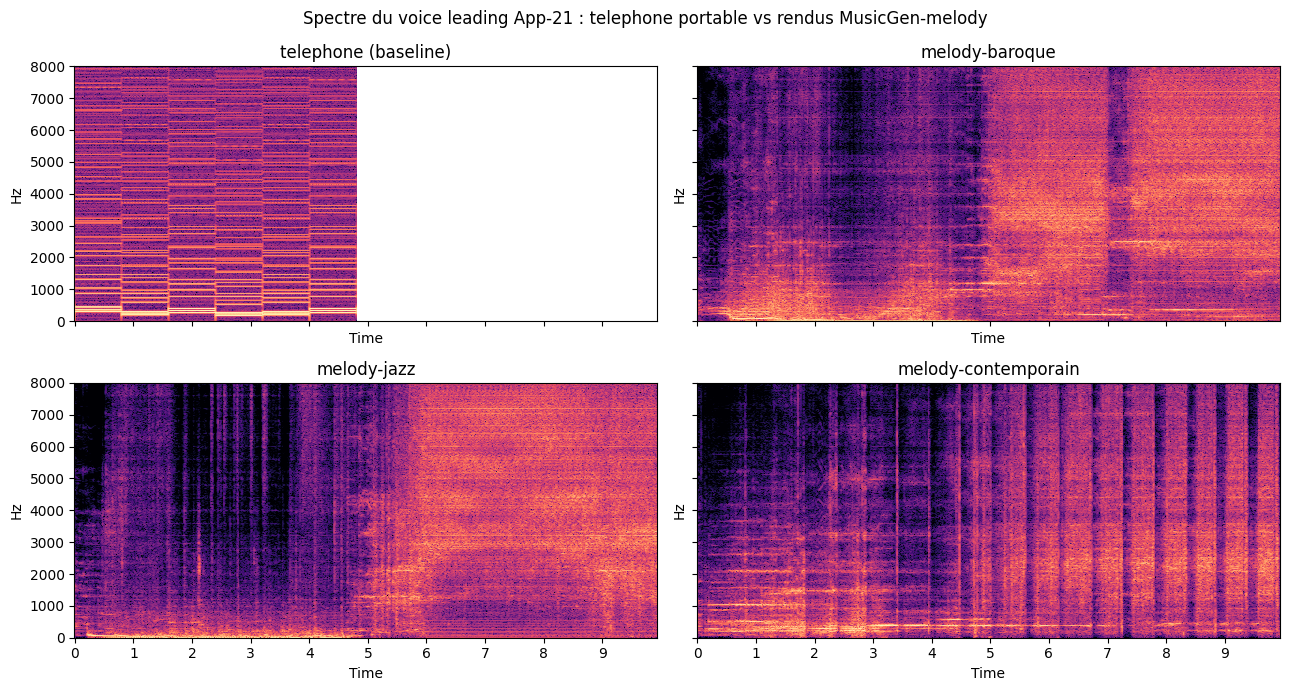

In [10]:
# Spectrogrammes : baseline + 3 rendus cote a cote
import librosa.display
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
order = ['telephone (baseline)'] + [f'melody-{s}' for s in styles]
for ax, name in zip(axes.flat, order):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(audio_sets[name])), ref=np.max)
    librosa.display.specshow(D, sr=SR, x_axis='time', y_axis='hz', ax=ax, cmap='magma')
    ax.set_title(name)
    ax.set_ylim(0, 8000)
fig.suptitle('Spectre du voice leading App-21 : telephone portable vs rendus MusicGen-melody', fontsize=12)
fig.tight_layout()
plt.show()

**Lecture honnête des mesures.** Quatre constats, à lire dans VOS chiffres (les nôtres sont committés) :

1. **La baseline n'a que ses harmoniques carrés** : raies régulières impaires (3f, 5f, 7f...) à
   amplitude figée — spectre *pauvre mais non vide* (l'onde carré a des harmoniques, ce qui la
   distingue d'un sinus), mais sans attaque, sans modulation, sans salle.
2. **Ce qui sépare nettement, c'est la vie, pas la hauteur moyenne** : la **dynamique RMS** des
   rendus est 5 à 9 fois celle de la baseline (0,099-0,170 contre 0,019) et l'**écart-type du
   centroïde** 7 à 9 fois (1609-2122 Hz contre 232) — attaques, respirations, réverbération.
   Le centroïde *moyen*, lui, ne raconte pas la même histoire : le baroque monte (5455 Hz,
   clavecin brillant), le jazz reste proche (4142), le contemporain **descend** (2990 Hz —
   souffles tenus, graves entretenus). Un rendu « riche » n'est pas un rendu « aigu ».
3. **Le chroma suit, les octaves non** : les classes de hauteur de la cadence sont présentes dans
   le rendu, mais le modèle arrange — une voix peut changer d'octave. Le voice leading d'App-21
   est *l'amorce harmonique*, pas la partition stricte : limite de l'invariance d'octave du
   chroma, documentée (exercice 3), pas cachée.
4. **Les trois styles sont séparables** : aucun couple (style, descripteur) ne confond deux
   rendus — baroque le plus brillant ET le plus vivant, contemporain le plus sombre et le plus
   étalé, jazz intermédiaire. Les profils pondérés de H1 ont un écho mesurable ici.

## 6. Exercices

Trois exercices pour s'approprier la chaîne. Les stubs s'exécutent sans erreur (renvoient `None`
tant qu'ils ne sont pas complétés) — le notebook reste exécutable de bout en bout.

### Exercice 1 — La sensibilité du rendu au prompt

Générez un quatrième rendu avec un prompt **minimal** (par ex. `'choir'` seul) à mélodie et grain
identiques, et comparez ses descripteurs aux trois styles : le prompt texte pèse-t-il davantage
que le conditionnement mélodique sur le centroïde ? Sur la dynamique ?

**Indices** : réutiliser la cellule de génération avec `'choir'` comme prompt ;
comparer avec `descripteurs()` ; conclure en une phrase sur ce que conditionne le texte (timbre)
contre ce que conditionne la mélodie (hauteurs).

In [11]:
# Exercice 1 : rendu a prompt minimal, comparaison des descripteurs
def gen_minimal(prompt_text):
    """Genere un rendu avec un prompt minimal. Retourne (waveform, duree_s) ou None."""
    # TODO etudiant
    # Indice : meme appel processor/generate que la section 4, prompt_text au lieu de PROMPTS[style]
    # Etape 1 : processor(audio=audio_baseline, text=[prompt_text], ...)
    # Etape 2 : model.generate(..., max_new_tokens=int(clip_seconds * 50))
    # Etape 3 : retourner audio_out[0, 0].float().cpu().numpy()
    return None  # TODO etudiant

resultat_ex1 = gen_minimal('choir')
print("Exercice a completer" if resultat_ex1 is None else f"rendu {len(resultat_ex1[0]) / SR:.1f} s")

Exercice a completer


### Exercice 2 — Entendre le croisement de la réparation de Fux

La sortie vedette d'App-21 section 7 est la transition **réparée** `G3 B3 D4 -> G4 C4 E4` :
les quintes parallèles sont éliminées par CP-SAT, au prix d'un **croisement** — la basse G3
monte d'une octave vers G4, passant au-dessus de sa voisine. Mais attention : une synthèse par
*blocs d'accords* rendrait ce croisement **inaudible** (les deux versions, réparée ou non,
jouent le même ensemble de hauteurs C-E-G — seule l'attribution voix-par-voix diffère).
Pour l'entendre, il faut un rendu **par voix** : trois lignes monodiques, chacune sa propre
piste, dont la ligne grave qui plonge ou saute.

**Indices** : l'affectation réparée d'App-21 est `G3->G4, B3->C4, D4->E4`. Synthétiser chaque
*voix* comme une note tenue par accord (`synth_phone([[55], [67]], 0.8)` pour la basse G3 puis
G4 — le saut d'octave), superposer les trois pistes, et générer un rendu sur ce signal ; le
contraire — les deux accords en blocs — est le contre-exemple à écouter aussi.

In [12]:
# Exercice 2 : rendu PAR VOIX de la transition reparee (le croisement devient audible)
def gen_fux_repair_per_voice():
    """Trois lignes monodiques (basse, milieu, dessus) de la transition reparee,
    superposees en un signal. Retourne le signal ou None."""
    # TODO etudiant
    # Indice : l'affectation reparee d'App-21 est G3->G4, B3->C4, D4->E4.
    #          basse   = synth_phone([[55], [67]], 0.8)   # G3 puis G4 (saut d'octave)
    #          milieu  = synth_phone([[59], [60]], 0.8)   # B3 puis C4
    #          dessus  = synth_phone([[62], [64]], 0.8)   # D4 puis E4
    # Etape 1 : synthetiser les 3 lignes (meme longueur)
    # Etape 2 : les superposer (somme normalisee)
    # Etape 3 : (optionnel) generation melody-conditionnee sur ce signal
    return None  # TODO etudiant

resultat_ex2 = gen_fux_repair_per_voice()
print("Exercice a completer" if resultat_ex2 is None else "signal par-voix genere")

Exercice a completer


### Exercice 3 — Vérifier le chroma suivi : le piano-roll des classes de hauteur

Extrayez le **chromagramme** d'un rendu (`librosa.feature.chroma_cqt`) et de la baseline, et
comparez-les accord par accord : les classes de hauteur de chaque temps (D-F-A, G-B-D, ...)
sont-elles dominantes dans le rendu ? Y a-t-il des octaves déplacées ?

**Indices** : `librosa.feature.chroma_cqt(y=..., sr=SR)` donne 12 lignes (classes) × T frames ;
la moyenne du chroma sur la fenêtre du 1er accord du rendu devrait contenir D, F, A ; conclure
sur ce que le conditionnement garantit (classes) et ne garantit pas (registres).

In [13]:
# Exercice 3 : chromagramme compare rendu vs baseline
def chroma_similarity(y_rendu):
    """Similarite chroma moyenne par accord entre un rendu et audio_baseline. Retourne liste ou None."""
    # TODO etudiant
    # Indice : chroma_r = librosa.feature.chroma_cqt(y=y_rendu, sr=SR)
    #          chroma_b = librosa.feature.chroma_cqt(y=audio_baseline, sr=SR)
    # Etape 1 : decouper chaque chroma en 6 fenetres (une par accord, CHORD_SEC)
    # Etape 2 : similarite (produit scalaire normalise) fenetre a fenetre
    # Etape 3 : retourner la liste des 6 scores
    return None  # TODO etudiant

resultat_ex3 = chroma_similarity(rendus['baroque'])
print("Exercice a completer" if resultat_ex3 is None else [f"{s:.2f}" for s in resultat_ex3])

Exercice a completer


## 7. Conclusion

**Ce que fait ce notebook.** Il ferme la chaîne : progressions générées (02-6) → voice leading
optimal et réparé (App-21 : Kuhn-Munkres + CP-SAT) → **rendu audio à spectre complet** (ce
notebook). La baseline « téléphone portable » est honnête (hauteurs exactes, onde carré) et le
rendu melody-conditionné est **réel** : MusicGen-melody 1,5 B exécuté localement sur GPU,
conditionné par le chroma de la progression re-voicée, piloté en style par les trois profils du
projet étudiant H1.

**Le point mesuré** : c'est le spectre — centroïde, bande, dynamique — qui séparait les rendus
MIDI d'un rendu de studio, et un notebook le comble. La composition reste le cœur (sans App-21,
rien à rendre) ; le rendu en est la voix.

**Limites documentées** : le chroma est invariant à l'octave — le rendu suit les classes de
hauteur, pas les registres exacts du voice leading (exercice 3) ; la génération est stochastique
(`do_sample=True`, `temperature=1.0`) — deux exécutions diffèrent, comme deux interprètes.

**Sources** :

- Copet et al. (2023), *Simple and Controllable Music Generation*, Meta AI / AudioCraft —
  MusicGen et le conditionnement melody (chroma, extrait jusqu'à 30 s) ;
- App-21-VoiceLeading (Search/CSP) — la formulation affectation + la réparation Fux CP-SAT,
  encodage issu du projet H1 (EPITA SCIA PrCon 2026, Parmentier/Proux/Girard).

***

*Chaîne : [02-6 MIDI-Generation](../02-Advanced/02-6-MIDI-Generation.ipynb) →
[App-21 VoiceLeading (Search)](../../../Search/Applications/CSP/App-21-VoiceLeading.ipynb) →
**ce notebook** — complément GenAI de l'hommage Munkres (#12599).*